In [1]:
from mpi4py import MPI
import numpy as np
import matplotlib.pyplot as plt

from h5 import HDFArchive
import coqui

Hartree_eV = 27.211386245988

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin065 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


Starting serial run at: 2026-05-21 14:05:34.260431


## Ab Initio GW+EDMFT for Quantum Materials

This tutorial provides an introduction ot the ab initio GW+EDMFT method for quantum materials. 

This tutorial will cover:
1. Initializing and executing a GW+EDMFT calculation

2. Important parameters and settings when performing GW+EDMFT calculations

3. Important observales/results obtained from GW+EDMFT calculations

## Realizing GW+EDMFT: CoQuí and TRIQS

<figure style="text-align: center;">
 <img src="../../images/gw_edmft_workflow.png" alt="GW+EDMFT workflow using CoQuí + TRIQS" width="65%">
 <figcaption>GW+EDMFT workflow using CoQuí + TRIQS.</figcaption>
</figure>

[Brief overivew on GW+EDMFT methodology and the physics it captures. Then describe the workflow for a self-consistent GW+EDMFT calculation and how CoQuí and TRIQS work together to realize it.] 

The workflow is split between CoQuí (orange boxes) and TRIQS (blue boxes), each with distinct responsibilities.

### Why CoQuí

1. Efficient ab initio GW with full frequency dependence in the full Hilbert space
2. Downfolding routines for projecting lattice $G$ and $W$ into MLWF subspaces and building impurity actions
3. Upfolding routines for embedding impurity corrections back into the lattice problem

[Brief decription on ModEST and CT-SEG impurity solver. We may need more details on CT-QMC solver since CoQui's users may have zero experience with TRIQS and its solvers, such as in [the solid_dmft tutorial](https://github.com/TRIQS/tutorials/blob/3.3.x/AbinitioDMFT/01-solid_dmft.ipynb).]
### Why TRIQS-ModEST and CT-SEG

1. Flexible mapping from MLWFs to impurity subspaces
2. Support for multiple impurities
3. Block structures and symmetry constraints that reduce cost and improve stability

Together, CoQuí handles full-basis tasks (GW, downfolding, upfolding), while TRIQS handles impurity-space construction and solution.

## Test system: NiO (paramagnetic charge-transfer insulator)

<figure style="text-align: center;">
 <img src="../../images/nio_gw_edmft_summary.png" alt="NiO" width="80%">
</figure>

Throughout this notebook, we use paramagnetic NiO as a representative correlated material.

**Physics background**
- NiO is a classic charge-transfer insulator with strong Ni 3d–O 2p hybridization.
- This makes double counting a central challenge in DFT+DMFT-type workflows.
- DFT and GW alone do not fully capture the insulating state.
- The Mott gap opens primarily in Ni $e_g$ orbitals and requires local correlations (DMFT/EDMFT).

**Starting point in this notebook**
- A pre-computed self-consistent GW solution for NiO
- MLWFs from a large window including Ni $d$ and O $p$ states (8 orbitals total)


In [2]:
# TODO run a python script to copy the following input files to here
# - `../../data/qe_inputs/nio/555/mlwf_dp/nio.mlwf.h5`: MLWFs for Ni $d$ + O $p$
# - `../../data/coqui/nio/555/nio.mbpt.h5`: pre-computed GW solution

### Section 1: GW+EDMFT 

[This section will focus on introducing `coqui.run_gw_edmft` function and its input/output. We will then show how to use it to run a self-consistent GW+EDMFT calculation for NiO, and analyze the results (spectral functions, self-energies, etc.) to see how the insulating state emerges.]

In [ ]:
!cat gw_edmft_params.toml

In [5]:
dmft_h5 = "/mnt/home/cyeh/ceph/coqui-tutorial/quickstart/04_gw_edmft/coqui/02_gw_edmft/rpa_screen/nio.dmft.h5"
with HDFArchive(dmft_h5, 'r') as f:
    print(f)

HDFArchive (partial view) with the following content:
  dmft : subgroup
  imaginary_fourier_transform : subgroup


In [2]:
dmft_h5 = "../nio_555/coqui/nio.dmft.h5"
iaft = coqui.IAFT.from_coqui_chkpt(dmft_h5)

niter, solver_inputs = 50, []
for it in range(niter):
    inp = coqui.dmft.read_impurity_chkpt(dmft_h5, read="inputs", iteration=it)
    solver_inputs.append(inp[0])

solver_results = []
for it in range(niter):
    res = coqui.dmft.read_impurity_chkpt(dmft_h5, read="results", iteration=it)
    solver_results.append(res[0])

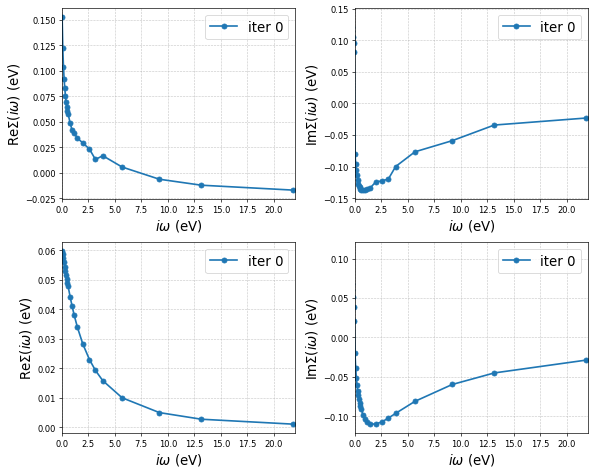

In [6]:
Hartree_eV = 1.0
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(2, 2, figsize=(10,8), dpi=60)
offset = 0
for i in range(offset,len(solver_results), 1):
    ax[0,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][0][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[0,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][0][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][0][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][0][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')

xmin, xmax = 0, 22.0
for i in range(2):
    ax[i,0].set_xlim(xmin, xmax)
    ax[i,0].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,0].set_ylabel("Re$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,0].legend(loc=1, ncol=2, fontsize=16)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

for i in range(2):
    ax[i,1].set_xlim(xmin, xmax)
    #ax[i,1].set_ylim(-2.5, 0.0)
    ax[i,1].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,1].set_ylabel("Im$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,1].legend(loc=1, ncol=2, fontsize=16)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
 
plt.tight_layout()
Hartree_eV = 27.211386245988

In [7]:
from coqui.dmft.ctseg.ctseg_utils import tail_fit, fill_dlr_imfreq_gf
from triqs.gf import *
from triqs.plot.mpl_interface import oplot

def sigma_tail_fit(Sigma_dlr_iw_raw, gf_struct, Sigma_infty=None, 
                   fit_min_w=1.8, fit_max_w=4.5, fit_max_moment=12):
    # get raw self-energy on a uniform Matsubara mesh 
    wmax, eps = Sigma_dlr_iw_raw.mesh.w_max, Sigma_dlr_iw_raw.mesh.eps
    Sigma_iw_raw = make_gf_imfreq(make_gf_dlr(Sigma_dlr_iw_raw), n_iw = 1000)

    # get analytic moment 
    if Sigma_infty is not None:
        Sigma_moments = {}
        for i, struct in enumerate(gf_struct):
            Sigma_moments[struct[0]] = np.array([Sigma_infty[i]], dtype=complex)
    else:
        Sigma_moments = None

    Sigma_iw_fit = tail_fit(
        Sigma_iw_raw, 
        fit_min_w=fit_min_w, fit_max_w=fit_max_w, fit_max_moment=fit_max_moment, fit_known_moments=Sigma_moments
    )
    Sigma_iw_fit = fill_dlr_imfreq_gf(Sigma_iw_fit, wmax, eps)

    return Sigma_iw_fit

Tail fit for Σ(iω):
  fit window : ω = [1.1624, 14.9854] a.u.
  max moment : 12
  known moments provided : yes



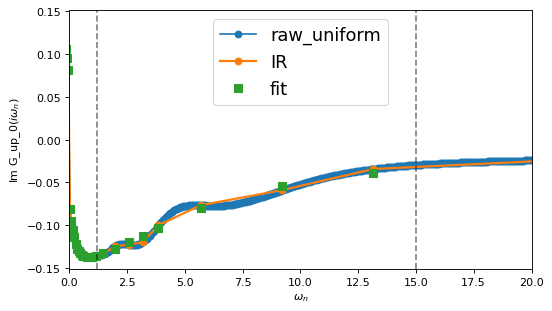

In [16]:
wmin, wmax, order = 1.2, 15.0, 12
Sigma_iw_fit = sigma_tail_fit(
    solver_results[0]['Sigma_iw'], solver_results[0]['gf_struct'], solver_results[0]['Sigma_infty'], 
    wmin, wmax, order
)
Sigma_iw_raw = make_gf_imfreq(make_gf_dlr(solver_results[0]['Sigma_iw']), n_iw = 1000)

fig, ax = plt.subplots(1, figsize=(7,4), dpi=80)
ax.oplot(Sigma_iw_raw['up_0'].imag, marker='o', label="raw_uniform")
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta
ax.plot(iw_mesh_f, solver_results[0]['Sigma_iw_data'][0][:,0,0].imag, 
        linestyle='-', marker='o', markersize=6, linewidth=2, label=f'IR')
ax.oplot(Sigma_iw_fit['up_0'].imag, marker='s', linestyle='--', markersize=8, label="fit")
ax.axvline(x=wmin, color='black', alpha=0.5, linestyle='--')
ax.axvline(x=wmax, color='black', alpha=0.5, linestyle='--')
ax.set_xlim(0, 20.0)
#ax.set_ylim(-0.1, 0.00)
ax.legend(fontsize=16)
plt.tight_layout()

#### 🔹 Convergence checking 

[Discuss the importance indicators/observables for checking convergence of GW+EDMFT calculations, inclulding impurity occupations, static screened interactions, chemical potential shift for impurity, specral weights at Fermi level $G(\tau=\beta/2)$, etc.. Convergence criteria of GW+EDMFT: $G_{loc} = G_{imp}$ and $W_{loc} = W_{imp}$ (if screen_type = rpa), changes in Weiss fields.]

[Mention how these indicators can be accessed from CoQui's GW+EDMFT output, and show examples of how to plot them as a function of iteration number to check for convergence.]

### Section 2: Analaysis of GW+EDMFT results

[In the previous section, we run a simple GW+EDMFT calculation with a couple of iterations and check the convergence of different indicators. In this section, we will analyze the results of a converged GW+EDMFT calculation (perhaps from a well-converged pre-computed checkpoint) to see how the insulating state emerges in NiO, and how the spectral functions, self-energies, and screened interactions from GW+EDMFT compared to GW alone.]

#### 🔹 Local spectral functions from impurity Green's function

#### 🔹 Local spectrum of the impurity screened interaction

#### 🔹 Effective interactions for V $t_{2g}$ and its comparison with cRPA

#### 🔹 Optical absorption spectrum

The GW+BSE method calculate the neutral excitation spectrum, presented as an optical absorption spectrum or the macroscopic dielectric function $\epsilon_M(\omega)$. In particular, the imaginary part of $\epsilon_M(\omega)$ is proportional to the optical absorption spectrum, which can be measured experimentally. 


#### 🔹 Local correlation functions

[TODO Check the dmft checkpoint file and visualize the local Green's function and local screened interaction $G_{\mathrm{loc}}$ and $W_{\mathrm{loc}}$.]

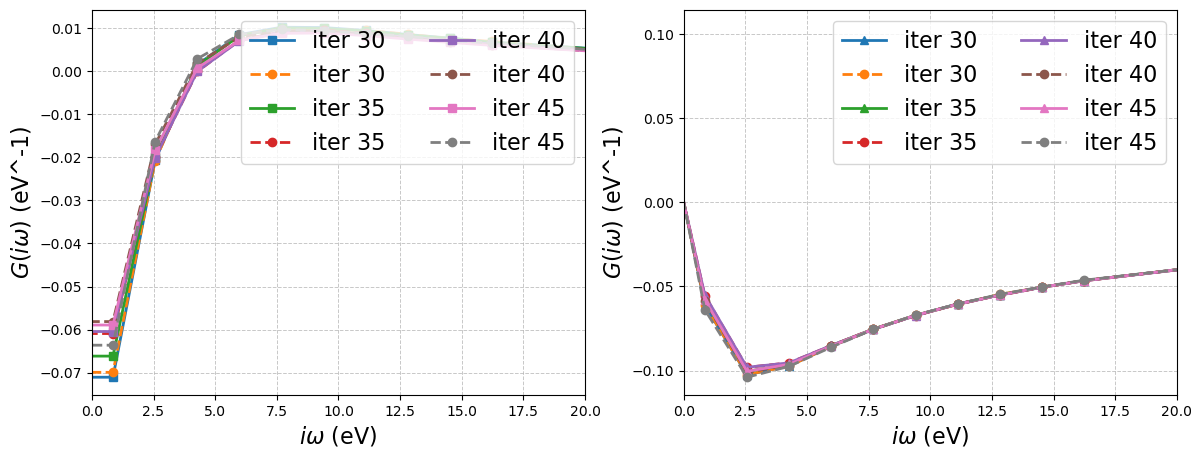

In [5]:
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(1, 2, figsize=(14,5), dpi=100)
offset = 30
for i in range(offset, len(solver_inputs),5):
    G_iw_t2g = iaft.tau_to_w(solver_inputs[i]['Gloc_t'][0], 'f')

    ax[0].plot(iw_mesh_f, G_iw_t2g[:,0,0].real/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[0].plot(iw_mesh_f, solver_results[i]['G_iw_data'][0][:,0,0].real/Hartree_eV, 
            linestyle='--', marker='o', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_f, G_iw_t2g[:,0,0].imag/Hartree_eV, 
            linestyle='-', marker='^', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_f, solver_results[i]['G_iw_data'][0][:,0,0].imag/Hartree_eV, 
            linestyle='--', marker='o', linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i].set_xlim(0, 20)
    ax[i].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i].set_ylabel("$G(i\omega)$ (eV^-1)", fontsize=16)
    ax[i].legend(ncol=2, loc=1, fontsize=16)
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

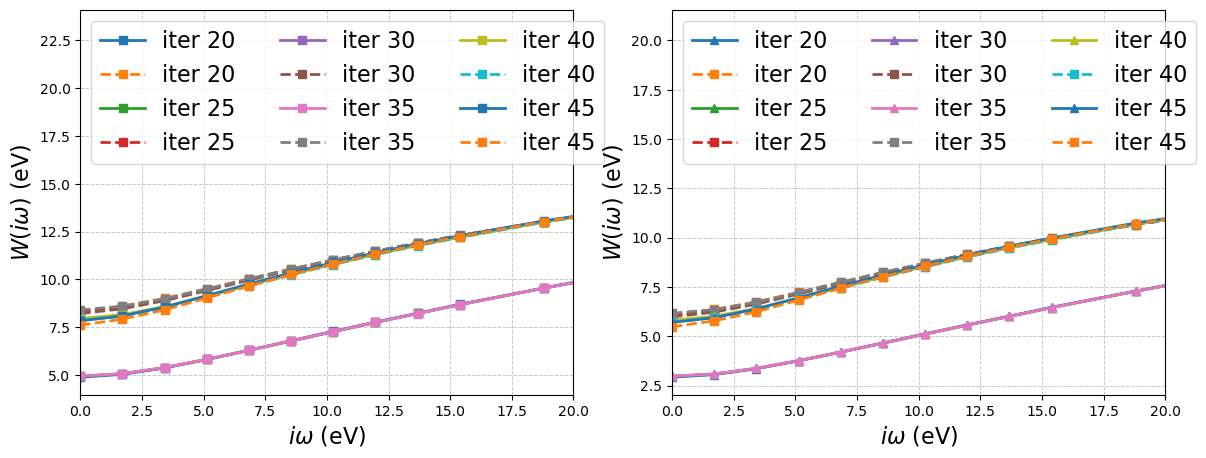

In [7]:
iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(1, 2, figsize=(14,5), dpi=100)
offset = 20
for i in range(offset, len(solver_inputs),5):
    W_iw = iaft.tau_to_w_phsym(solver_inputs[i]['Wloc_t'], 'boson')
    ax[0].plot(iw_mesh_b, (W_iw[:,0,0,0,0].real+solver_inputs[i]['Vloc'][0,0,0,0].real)*Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[0].plot(iw_mesh_b, (solver_results[i]['W_iw_data'][0][:,0,0].real+solver_inputs[i]['Vloc'][0,0,0,0].real)*Hartree_eV, 
            linestyle='--', marker='s', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_b, (W_iw[:,0,0,1,1].real+solver_inputs[i]['Vloc'][0,0,1,1].real)*Hartree_eV, 
            linestyle='-', marker='^', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_b, (solver_results[i]['W_iw_data'][0][:,0,1].real+solver_inputs[i]['Vloc'][0,0,1,1].real)*Hartree_eV, 
            linestyle='--', marker='s', linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i].set_xlim(0, 20)
    #ax[i].set_ylim(-1, 10)
    ax[i].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i].set_ylabel("$W(i\omega)$ (eV)", fontsize=16)
    ax[i].legend(ncol=3, loc=2, fontsize=16)
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

#### 🔹 Impurity problem - Weiss fields 
[TODO Check the dmft checkpoint file and visualize the impurity Weiss fields $\mathcal{G}$ and $\mathcal{U}$.]

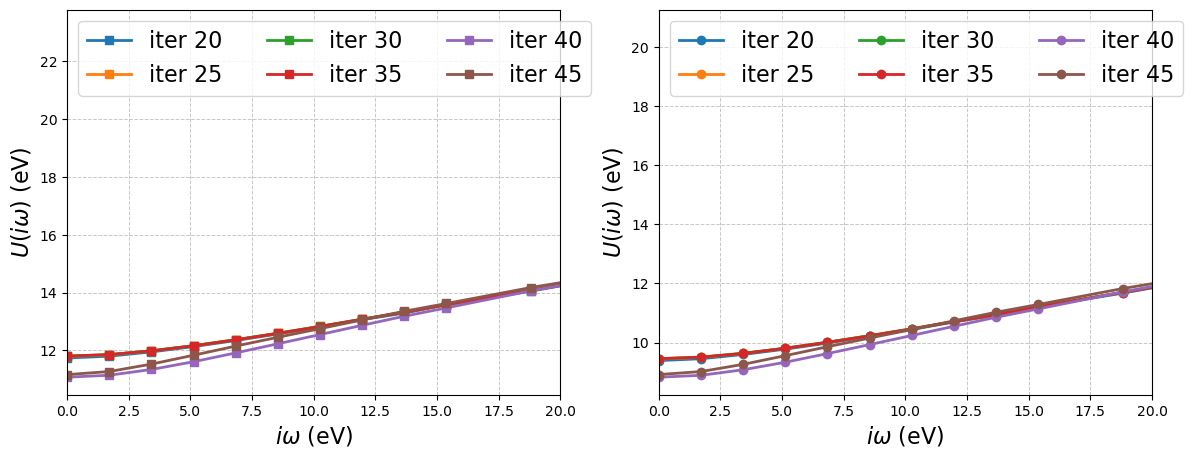

In [9]:
iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(1, 2, figsize=(14,5), dpi=100)
offset = 20
for i in range(offset,len(solver_inputs),5):
    ax[0].plot(iw_mesh_b, (solver_inputs[i]['u_weiss_iw'][:,0,0,0,0].real+solver_inputs[i]['Vloc'][0,0,0,0].real)*Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[1].plot(iw_mesh_b, (solver_inputs[i]['u_weiss_iw'][:,0,0,1,1].real+solver_inputs[i]['Vloc'][0,0,1,1].real)*Hartree_eV, 
            linestyle='-', marker='o', linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i].set_xlim(0, 20)
    #ax[i].set_ylim(2, 18)
    ax[i].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i].set_ylabel("$U(i\omega)$ (eV)", fontsize=16)
    ax[i].legend(ncol=3, loc=2, fontsize=16)
    ax[i].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

#### 🔹 Impurity solution
[TODO Check the dmft checkpoint file and visualize the impurity solutions $\Sigma_{\mathrm{imp}}$ and $\Pi_{\mathrm{imp}}$, and compare to the double counting solution.]

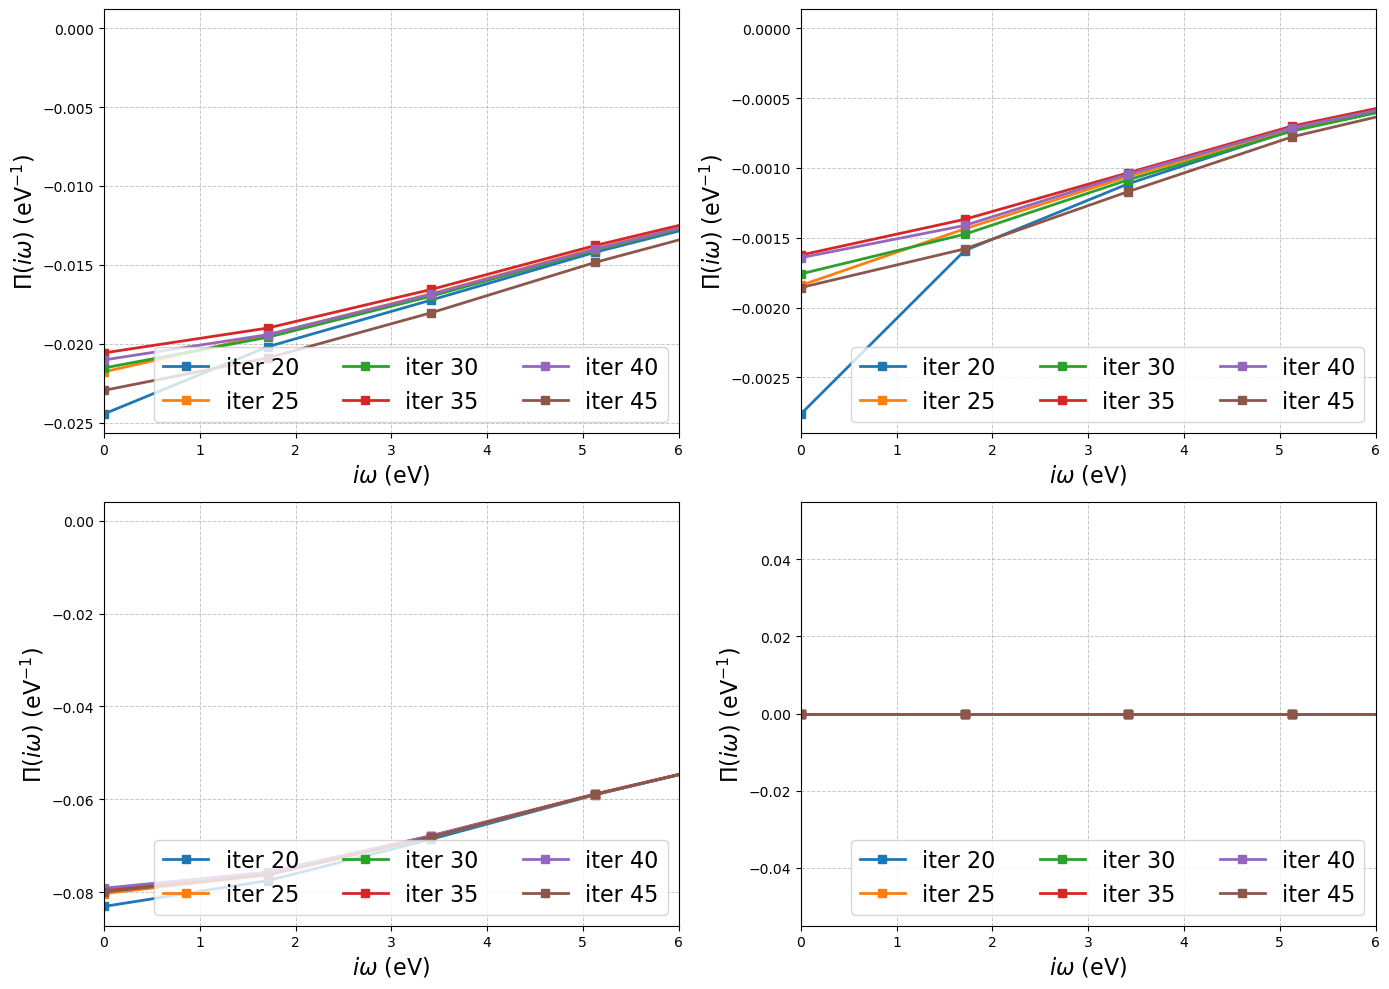

In [11]:
iw_mesh_b = iaft.wn_mesh('boson', positive_only=True) * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(2, 2, figsize=(14,10), dpi=100)

offset = 20
for i in range(offset,len(solver_results), 5):
    ax[0,0].plot(iw_mesh_b, (solver_results[i]['Pi_iw_data'][0][:,0,0].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[0,1].plot(iw_mesh_b, (solver_results[i]['Pi_iw_data'][0][:,0,1].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[1,0].plot(iw_mesh_b, (solver_results[i]['Pi_iw_dc_data'][0][:,0,0].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')
    ax[1,1].plot(iw_mesh_b, (solver_results[i]['Pi_iw_dc_data'][0][:,0,1].real)/Hartree_eV, 
            linestyle='-', marker='s', linewidth=2, label=f'iter {i}')

for ij in range(4):
    i = ij//2
    j = ij%2
    ax[i,j].set_xlim(0, 6)
    ax[i,j].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,j].set_ylabel("$\Pi(i\omega)$ (eV$^{-1}$)", fontsize=16)
    ax[i,j].legend(ncol=3, loc=4, fontsize=16)
    ax[i,j].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,j].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

plt.tight_layout()

In [12]:
for i in range(len(solver_results)):
    vhf_dc = solver_results[i]['Sigma_infty_dc'][0][0,0]
    vhf_imp = solver_results[i]['Sigma_infty'][0][0,0]
    print(f"Vhf imp = {vhf_imp.real}, Vhf dc = {vhf_dc.real}, diff = {vhf_imp.real-vhf_dc.real}")

Vhf imp = 0.7941825568966521, Vhf dc = 0.7942327118335192, diff = -5.015493686710837e-05
Vhf imp = 0.762654585265286, Vhf dc = 0.762719076191341, diff = -6.44909260550941e-05
Vhf imp = 0.7064564926398, Vhf dc = 0.706623003511114, diff = -0.0001665108713139185
Vhf imp = 0.64354233172101, Vhf dc = 0.6434876575711619, diff = 5.467414984816621e-05
Vhf imp = 0.5847151987212874, Vhf dc = 0.5845877660615963, diff = 0.00012743265969106243
Vhf imp = 0.534035288492609, Vhf dc = 0.5340340724513288, diff = 1.2160412801165421e-06
Vhf imp = 0.4921339653793162, Vhf dc = 0.49222296608330846, diff = -8.900070399225912e-05
Vhf imp = 0.45890770699283995, Vhf dc = 0.45897782318205194, diff = -7.011618921198837e-05
Vhf imp = 0.43352430371954154, Vhf dc = 0.4334761849841665, diff = 4.8118735375024535e-05
Vhf imp = 0.41358435993696613, Vhf dc = 0.4135075248889256, diff = 7.683504804051333e-05
Vhf imp = 0.39815479881848037, Vhf dc = 0.3980634783642142, diff = 9.132045426618607e-05
Vhf imp = 0.3865244737631163

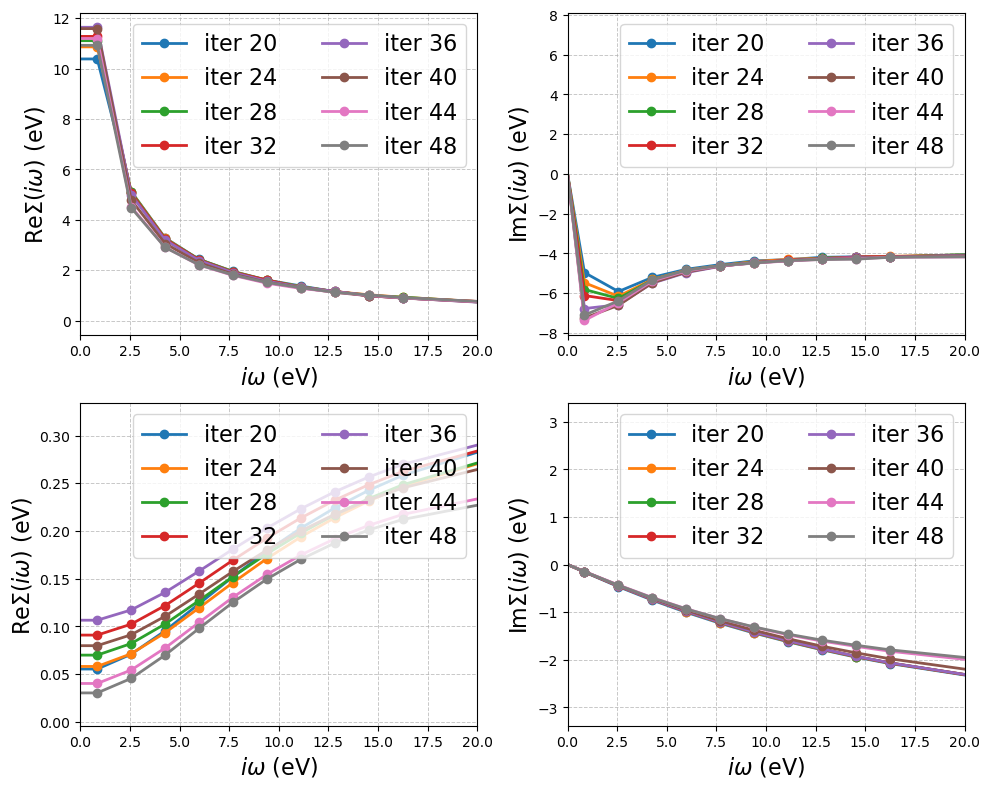

In [16]:
iw_mesh_f = iaft.wn_mesh('fermion') * np.pi / iaft.beta * Hartree_eV

fig, ax = plt.subplots(2, 2, figsize=(10,8), dpi=100)
offset = 20
for i in range(offset,len(solver_results), 4):
    ax[0,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][0][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[0,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_data'][0][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,0].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][0][:,0,0].real*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')
    ax[1,1].plot(iw_mesh_f, solver_results[i]['Sigma_iw_dc_data'][0][:,0,0].imag*Hartree_eV, 
         linestyle='-', marker='o', markersize=6, linewidth=2, label=f'iter {i}')

for i in range(2):
    ax[i,0].set_xlim(0, 20)
    ax[i,0].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,0].set_ylabel("Re$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,0].legend(loc=1, ncol=2, fontsize=16)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,0].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

for i in range(2):
    ax[i,1].set_xlim(0, 20)
    #ax[i,1].set_ylim(-2.5, 0.0)
    ax[i,1].set_xlabel("$i\omega$ (eV)", fontsize=16)
    ax[i,1].set_ylabel("Im$\Sigma(i\omega)$ (eV)", fontsize=16)
    ax[i,1].legend(loc=1, ncol=2, fontsize=16)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
    ax[i,1].grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
 
plt.tight_layout()